In [4]:
import numpy as np
import matplotlib.pyplot as plt
import random
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split



Eğitim verisi boyutu: (2000, 100, 100, 3)
Test verisi boyutu: (400, 100, 100, 3)
Kedi sayısı: 1000, Köpek sayısı: 1000
Sınıf dağılımı kontrolü:
Toplam eğitim örnekleri: 2000
Kedi sayısı: 1000
Köpek sayısı: 1000
Eğitim sınıf dağılımı: {0.0: 156, 1.0: 164}
Validation sınıf dağılımı: {0.0: 155, 1.0: 165}
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_3 (Conv2D)           (None, 98, 98, 32)        896       
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 49, 49, 32)        0         
 g2D)                                                            
                                                                 
 dropout_4 (Dropout)         (None, 49, 49, 32)        0         
                                                                 
 conv2d_4 (Conv2D)           (None, 47, 47, 64)        18496     
               

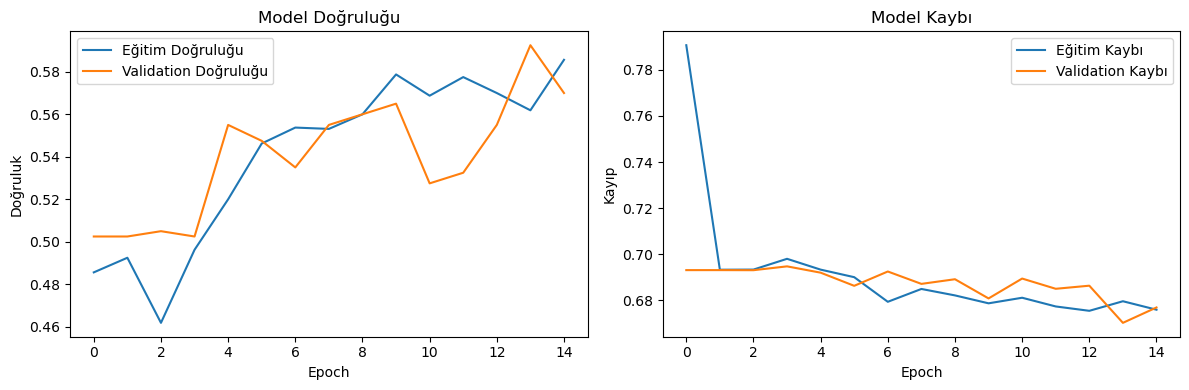

Test Doğruluğu: 0.6150
Test Kaybı: 0.6528


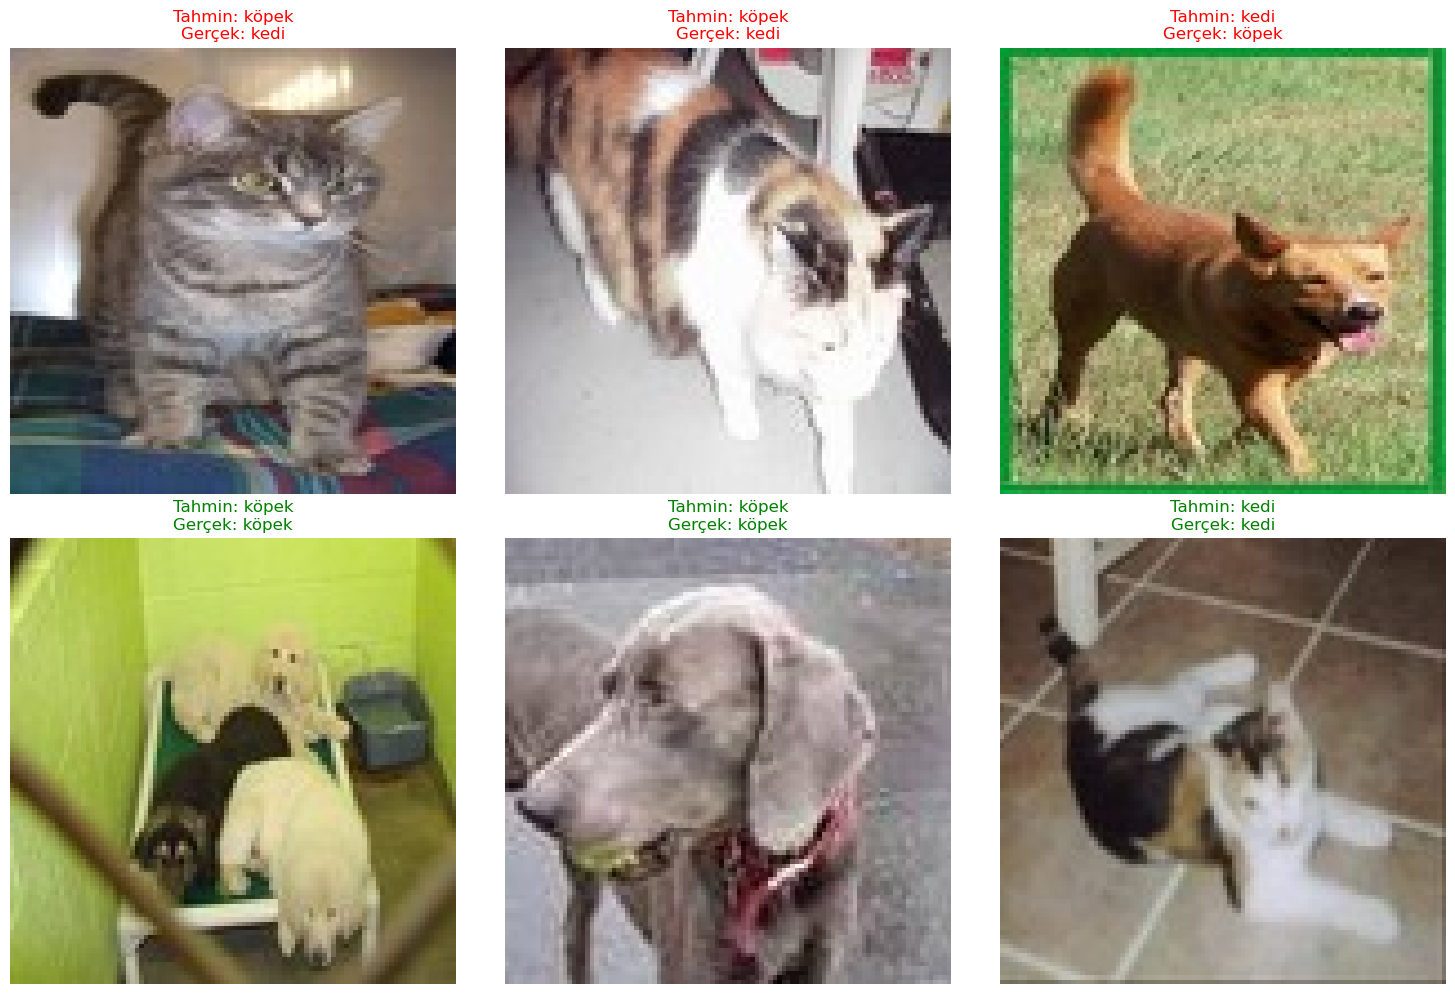

ModuleNotFoundError: No module named 'seaborn'

In [5]:
# Verileri yükleme
X_train = np.loadtxt("./data/input.csv", delimiter=",")
Y_train = np.loadtxt("./data/labels.csv", delimiter=",")
X_test = np.loadtxt("./data/input_test.csv", delimiter=",")
Y_test = np.loadtxt("./data/labels_test.csv", delimiter=",")

# Verileri yeniden şekillendirme
X_train = X_train.reshape(len(X_train), 100, 100, 3)
Y_train = Y_train.reshape(len(Y_train), 1)
X_test = X_test.reshape(len(X_test), 100, 100, 3)
Y_test = Y_test.reshape(len(Y_test), 1)

# Normalizasyon
X_train = X_train / 255.0
X_test = X_test / 255.0

print(f"Eğitim verisi boyutu: {X_train.shape}")
print(f"Test verisi boyutu: {X_test.shape}")
print(f"Kedi sayısı: {np.sum(Y_train == 1)}, Köpek sayısı: {np.sum(Y_train == 0)}")

# VERİLERİ KARIŞTIR
def shuffle_data(X, Y):
    """Verileri rastgele karıştır"""
    indices = np.arange(len(X))
    np.random.shuffle(indices)
    return X[indices], Y[indices]

# Verileri karıştır
X_train, Y_train = shuffle_data(X_train, Y_train)

# ImageDataGenerator
datagen = ImageDataGenerator(
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.3,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode="nearest",
    validation_split=0.2  # Validation için %20 ayır
)

# Model oluşturma
def create_model():
    model = Sequential()
    model.add(Conv2D(32, (3,3), activation="relu", input_shape=(100, 100, 3)))
    model.add(MaxPool2D((2,2)))
    model.add(Dropout(0.25))
    
    model.add(Conv2D(64, (3,3), activation="relu"))
    model.add(MaxPool2D((2,2)))
    model.add(Dropout(0.25))
    
    model.add(Conv2D(128, (3,3), activation="relu"))
    model.add(MaxPool2D((2,2)))
    model.add(Dropout(0.25))
    
    model.add(Flatten())
    model.add(Dense(512, activation="relu"))
    model.add(Dropout(0.5))
    model.add(Dense(1, activation="sigmoid"))
    
    model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])
    return model

# Data Generator'ları oluştur
train_generator = datagen.flow(
    X_train, Y_train,
    batch_size=32,
    subset='training',
    shuffle=True,
    seed=42
)

validation_generator = datagen.flow(
    X_train, Y_train,
    batch_size=32,
    subset='validation',
    shuffle=False,
    seed=42
)

# SINIF DAĞILIMINI KONTROL ETME (DÜZELTİLMİŞ)
print("Sınıf dağılımı kontrolü:")
print(f"Toplam eğitim örnekleri: {len(X_train)}")
print(f"Kedi sayısı: {np.sum(Y_train == 1)}")
print(f"Köpek sayısı: {np.sum(Y_train == 0)}")

# Train ve validation indekslerini alarak sınıf dağılımını kontrol et
def check_class_distribution(generator, generator_name):
    """Generator'daki sınıf dağılımını kontrol et"""
    all_labels = []
    
    # Birkaç batch'ten label'ları topla
    for i in range(min(10, len(generator))):  # İlk 10 batch veya daha az
        _, batch_labels = generator.next()
        all_labels.extend(batch_labels.flatten())
    
    unique, counts = np.unique(all_labels, return_counts=True)
    print(f"{generator_name} sınıf dağılımı: {dict(zip(unique, counts))}")

# Sınıf dağılımını kontrol et
check_class_distribution(train_generator, "Eğitim")
check_class_distribution(validation_generator, "Validation")

# Generator'ları resetle (ileri adım için)
train_generator.reset()
validation_generator.reset()

# Modeli oluştur
model = create_model()

# Model özeti
model.summary()

# Modeli eğit
print("Eğitim başlıyor...")
history = model.fit(
    train_generator,
    epochs=15,
    validation_data=validation_generator,
    steps_per_epoch=len(train_generator),
    validation_steps=len(validation_generator),
    verbose=1
)

# Eğitim geçmişini görselleştir
def plot_training_history(history):
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Eğitim Doğruluğu')
    plt.plot(history.history['val_accuracy'], label='Validation Doğruluğu')
    plt.title('Model Doğruluğu')
    plt.xlabel('Epoch')
    plt.ylabel('Doğruluk')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Eğitim Kaybı')
    plt.plot(history.history['val_loss'], label='Validation Kaybı')
    plt.title('Model Kaybı')
    plt.xlabel('Epoch')
    plt.ylabel('Kayıp')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

plot_training_history(history)

# Test et
test_loss, test_accuracy = model.evaluate(X_test, Y_test, verbose=0)
print(f"Test Doğruluğu: {test_accuracy:.4f}")
print(f"Test Kaybı: {test_loss:.4f}")

# Örnek tahminler
def show_predictions(model, X_test, Y_test, num_samples=6):
    plt.figure(figsize=(15, 10))
    indices = random.sample(range(len(X_test)), num_samples)
    
    for i, idx in enumerate(indices):
        plt.subplot(2, 3, i+1)
        plt.imshow(X_test[idx])
        
        # Tahmin yap
        prediction = model.predict(X_test[idx].reshape(1, 100, 100, 3), verbose=0)
        predicted_class = "kedi" if prediction > 0.5 else "köpek"
        actual_class = "kedi" if Y_test[idx] == 1 else "köpek"
        
        # Renk: doğru yeşil, yanlış kırmızı
        color = 'green' if predicted_class == actual_class else 'red'
        
        plt.title(f"Tahmin: {predicted_class}\nGerçek: {actual_class}", color=color)
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Tahminleri göster
show_predictions(model, X_test, Y_test)

# Confusion matrix
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

def plot_confusion_matrix(model, X_test, Y_test):
    # Tüm test verisi için tahmin yap
    y_pred = model.predict(X_test, verbose=0)
    y_pred_binary = (y_pred > 0.5).astype(int)
    
    # Confusion matrix
    cm = confusion_matrix(Y_test, y_pred_binary)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Köpek', 'Kedi'],
                yticklabels=['Köpek', 'Kedi'])
    plt.title('Confusion Matrix')
    plt.ylabel('Gerçek Değer')
    plt.xlabel('Tahmin Edilen Değer')
    plt.show()
    
    # Classification report
    print("Classification Report:")
    print(classification_report(Y_test, y_pred_binary, 
                               target_names=['Köpek', 'Kedi']))

plot_confusion_matrix(model, X_test, Y_test)